# Population Structure Analysis Pipeline – STRs
### Dataset: 1000 Genomes Project – Short Tandem Repeats (STRs)

**Workflow:** CSV → Filtering → PCA → Clustering → Supervised Classification

---

## 0. Imports

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SUPER_COLORS = {
    'AFR': '#E41A1C',
    'AMR': '#FF7F00',
    'EAS': '#4DAF4A',
    'EUR': '#377EB8',
    'SAS': '#984EA3',
}

print('✅ Imports done')

✅ Imports done


---
## 1. Configuration

In [11]:
# ── Directories ───────────────────────────────────────────────────────────────
WORKDIR  = Path('Exercise2_files')
DATADIR  = WORKDIR / 'STR_data'          # put downloaded CSV files here
OUTDIR   = WORKDIR / 'STR_analysis'
PLOTDIR  = OUTDIR / 'plots'

for d in [DATADIR, OUTDIR, PLOTDIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Which chromosome CSV to use ───────────────────────────────────────────────
CHR = 1

# ── Panel file (reuse from Exercise 1) ───────────────────────────────────────
PANEL_PATH = Path('1000G_analysis') / '00_raw' / 'sample_panel.tsv'

# ── Filtering thresholds ──────────────────────────────────────────────────────
MAX_MISSING  = 0.1    # drop STRs missing in > 10% of samples
MIN_VARIANCE = 0.01   # drop monomorphic loci

# ── PCA ───────────────────────────────────────────────────────────────────────
N_PCS = 20

# ── Clustering ────────────────────────────────────────────────────────────────
N_CLUSTERS = 5        # matches 5 superpopulations

print('✅ Config set')

✅ Config set


---
## 2. Load Data

In [6]:
# ── Find the chromosome CSV ───────────────────────────────────────────────────
csv_files = list(DATADIR.glob(f'*chr{CHR}*.csv')) + list(DATADIR.glob(f'*{CHR}*.csv'))
if not csv_files:
    raise FileNotFoundError(
        f'No CSV found for chr{CHR} in {DATADIR}.\n'
        f'Files present: {list(DATADIR.glob("*"))}')
CSV_PATH = csv_files[0]
print(f'Loading: {CSV_PATH}')

raw = pd.read_csv(CSV_PATH, index_col=0)
print(f'Raw shape: {raw.shape}')
raw.iloc[:4, :5]

Loading: Exercise2_files/STR_data/kg_matrix_chr1.csv
Raw shape: (30635, 3202)


,NA19024,HG03117,NA19120,HG03492,NA19238
0,23.0,23.0,23.5,23.0,24.0
1,24.5,25.0,25.0,26.0,24.5
2,19.0,19.0,18.0,19.0,19.0
3,20.5,23.0,23.0,22.0,23.0


In [7]:
# ── Orient so rows = samples, columns = STR loci ─────────────────────────────
# 1000G sample IDs look like HG00096 or NA12878
sample_pattern = re.compile(r'^(HG|NA)\d{5}$')

if sample_pattern.match(str(raw.index[0])):
    geno = raw.copy()
    print('Orientation: rows=samples, cols=loci  ✅')
else:
    geno = raw.T
    print('Transposed to: rows=samples, cols=loci  ✅')

print(f'Genotype matrix: {geno.shape[0]} samples x {geno.shape[1]} STR loci')
geno.iloc[:3, :5]

Transposed to: rows=samples, cols=loci  ✅
Genotype matrix: 3202 samples x 30635 STR loci


,0,1,2,3,4
NA19024,23.0,24.5,19.0,20.5,13.0
HG03117,23.0,25.0,19.0,23.0,13.0
NA19120,23.5,25.0,18.0,23.0,13.0


---
## 3. Filtering

| Filter | Threshold | Reason |
|--------|-----------|--------|
| Missing rate | < 10% per locus | Remove unreliable loci |
| Variance | > 0.01 | Remove monomorphic loci |

Before filtering: 30,635 STR loci
After missingness filter  : 29,446 loci
After variance filter     : 29,446 loci

Final matrix: 3202 samples x 29446 STR loci


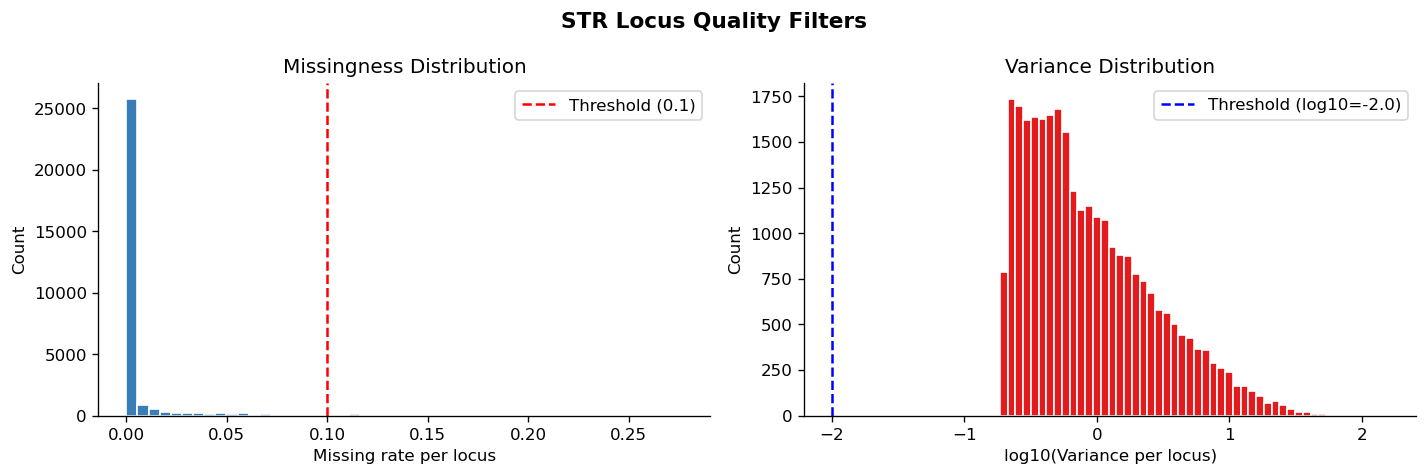

In [8]:
print(f'Before filtering: {geno.shape[1]:,} STR loci')

# Convert to numeric
geno = geno.apply(pd.to_numeric, errors='coerce')

# Filter 1: missingness
missing_rate = geno.isnull().mean(axis=0)
geno = geno.loc[:, missing_rate <= MAX_MISSING]
print(f'After missingness filter  : {geno.shape[1]:,} loci')

# Impute remaining missing with locus mean
geno = geno.fillna(geno.mean(axis=0))

# Filter 2: near-zero variance
locus_var = geno.var(axis=0)
geno = geno.loc[:, locus_var > MIN_VARIANCE]
print(f'After variance filter     : {geno.shape[1]:,} loci')
print(f'\nFinal matrix: {geno.shape[0]} samples x {geno.shape[1]} STR loci')

# ── Plot filters ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(missing_rate, bins=50, color='#377EB8', edgecolor='white')
axes[0].axvline(MAX_MISSING, color='red', ls='--', label=f'Threshold ({MAX_MISSING})')
axes[0].set(xlabel='Missing rate per locus', ylabel='Count', title='Missingness Distribution')
axes[0].legend()

axes[1].hist(np.log10(locus_var + 1e-10), bins=50, color='#E41A1C', edgecolor='white')
axes[1].axvline(np.log10(MIN_VARIANCE), color='blue', ls='--',
                label=f'Threshold (log10={np.log10(MIN_VARIANCE):.1f})')
axes[1].set(xlabel='log10(Variance per locus)', ylabel='Count', title='Variance Distribution')
axes[1].legend()

plt.suptitle('STR Locus Quality Filters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_filtering.png', bbox_inches='tight')
plt.show()

---
## 4. Load Population Panel

In [17]:
panel = pd.read_csv(PANEL_PATH, sep=r'\s+')
panel.columns = [c.lower().replace(' ', '_') for c in panel.columns]
col_map = {'sample': 'IID', 'super_population': 'super_pop', 'population': 'pop'}
panel = panel.rename(columns={k: v for k, v in col_map.items() if k in panel.columns})
if 'IID' not in panel.columns:
    panel = panel.rename(columns={panel.columns[0]: 'IID'})

# Match panel to samples in genotype matrix
common = geno.index.intersection(panel['IID'])
geno   = geno.loc[common]
meta   = panel.set_index('IID').loc[common].reset_index().rename(columns={'IID': 'index'}) 

print(f'Matched {len(common)} samples to panel')
print(meta['super_pop'].value_counts())

Matched 2504 samples to panel
super_pop
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64


---
## 5. PCA

In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(geno.values)

pca = PCA(n_components=N_PCS, random_state=42)
pcs = pca.fit_transform(X)

pct = pca.explained_variance_ratio_ * 100
print(f'PC1: {pct[0]:.1f}%  PC2: {pct[1]:.1f}%  PC3: {pct[2]:.1f}%')
print(f'Top {N_PCS} PCs explain {pct.sum():.1f}% of variance')

pc_df = pd.DataFrame(pcs, columns=[f'PC{i+1}' for i in range(N_PCS)], index=geno.index)
pc_df = pc_df.join(meta[['index', 'pop', 'super_pop']].set_index('index'))

PC1: 8.3%  PC2: 3.3%  PC3: 0.9%
Top 20 PCs explain 15.6% of variance


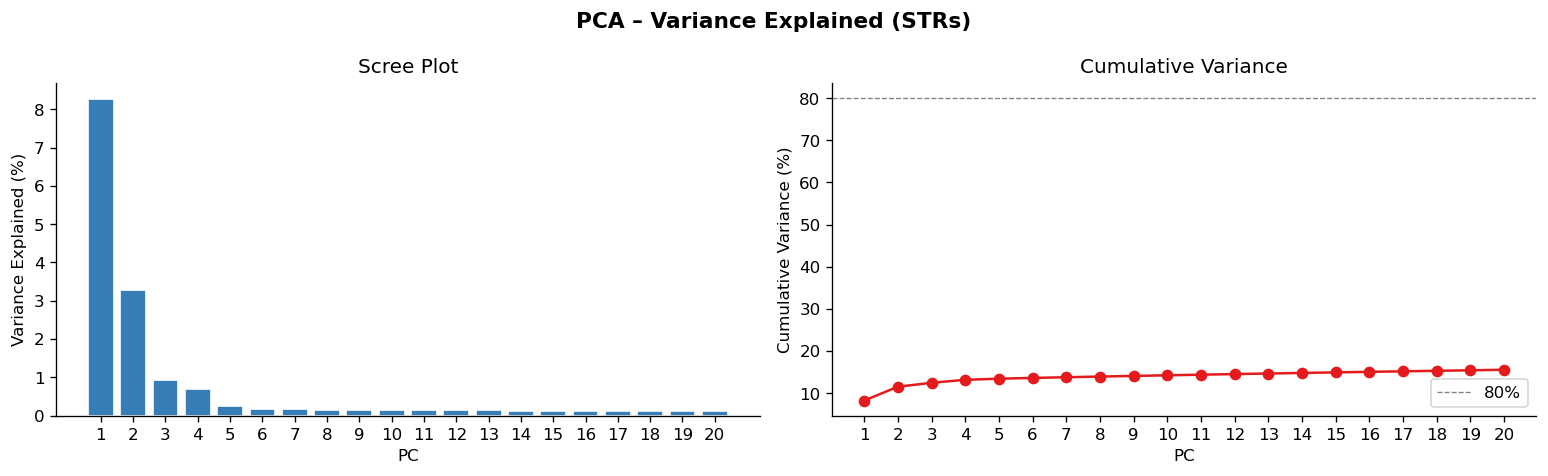

In [19]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, N_PCS+1), pct, color='#377EB8', edgecolor='white')
axes[0].set(xlabel='PC', ylabel='Variance Explained (%)', title='Scree Plot')
axes[0].set_xticks(range(1, N_PCS+1))

axes[1].plot(range(1, N_PCS+1), np.cumsum(pct), 'o-', color='#E41A1C')
axes[1].axhline(80, ls='--', color='grey', lw=0.8, label='80%')
axes[1].set(xlabel='PC', ylabel='Cumulative Variance (%)', title='Cumulative Variance')
axes[1].set_xticks(range(1, N_PCS+1))
axes[1].legend()

plt.suptitle('PCA – Variance Explained (STRs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_pca_variance.png', bbox_inches='tight')
plt.show()

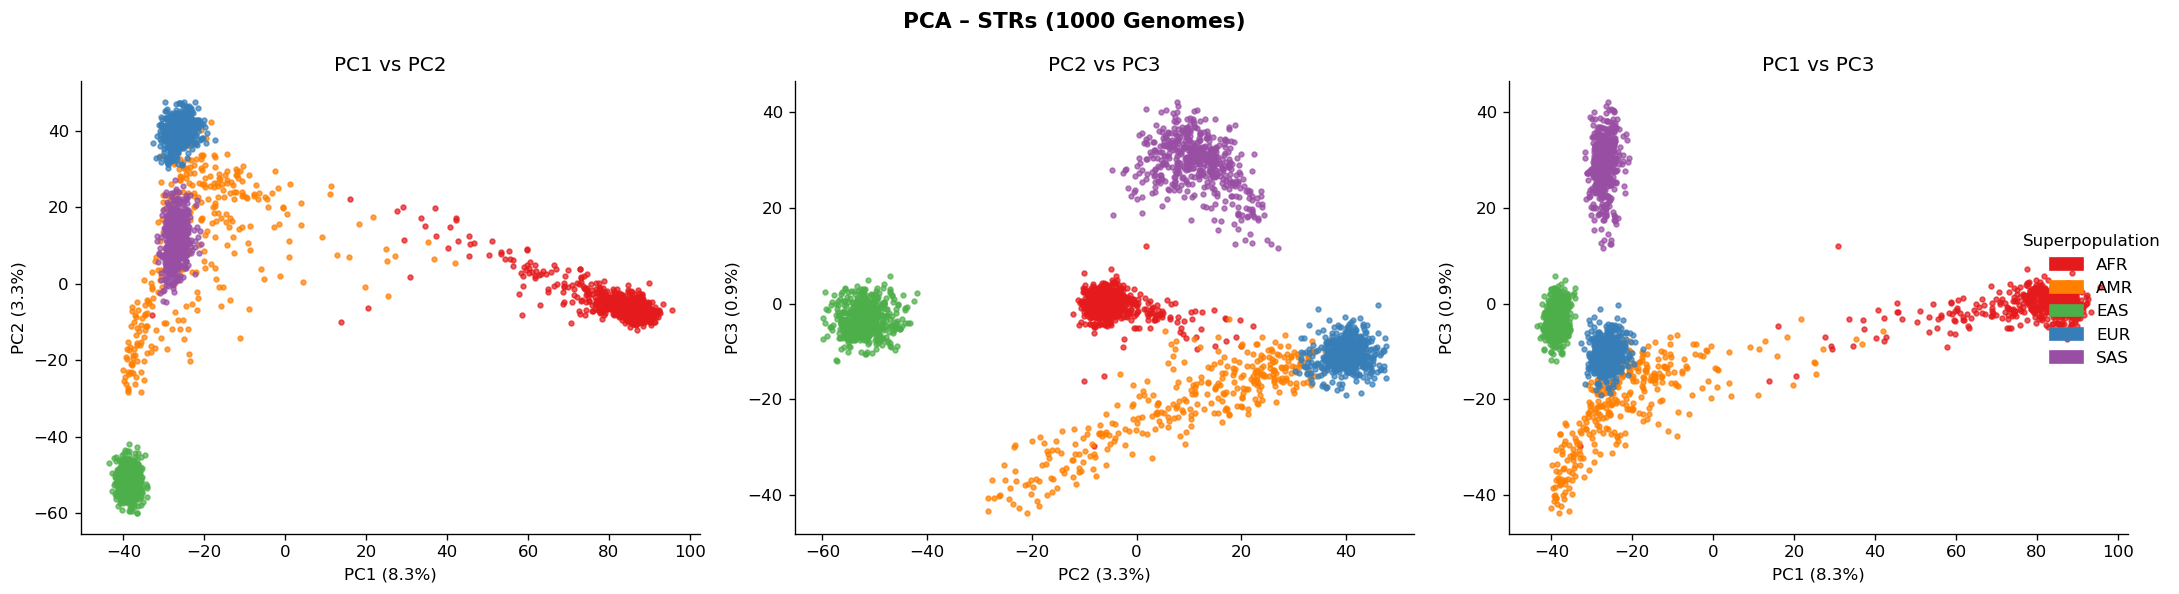

In [20]:
# PC scatter plots
pairs = [('PC1', 'PC2'), ('PC2', 'PC3'), ('PC1', 'PC3')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (pcx, pcy) in zip(axes, pairs):
    xi, yi = int(pcx[2:])-1, int(pcy[2:])-1
    for sp, grp in pc_df.groupby('super_pop'):
        ax.scatter(grp[pcx], grp[pcy],
                   c=SUPER_COLORS.get(sp, '#AAAAAA'),
                   s=8, alpha=0.7, label=sp, rasterized=True)
    ax.set(xlabel=f'{pcx} ({pct[xi]:.1f}%)',
           ylabel=f'{pcy} ({pct[yi]:.1f}%)',
           title=f'{pcx} vs {pcy}')

handles = [mpatches.Patch(color=v, label=k) for k, v in SUPER_COLORS.items()]
fig.legend(handles=handles, title='Superpopulation',
           loc='center right', bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.suptitle('PCA – STRs (1000 Genomes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_pca_scatter.png', bbox_inches='tight')
plt.show()

---
## 6. Clustering

Two approaches:
- **K-Means** on the top 10 PCs
- **Hierarchical clustering** dendrogram on a subset

Adjusted Rand Index (K-Means vs superpop): 0.873
  (1.0 = perfect, 0.0 = random)


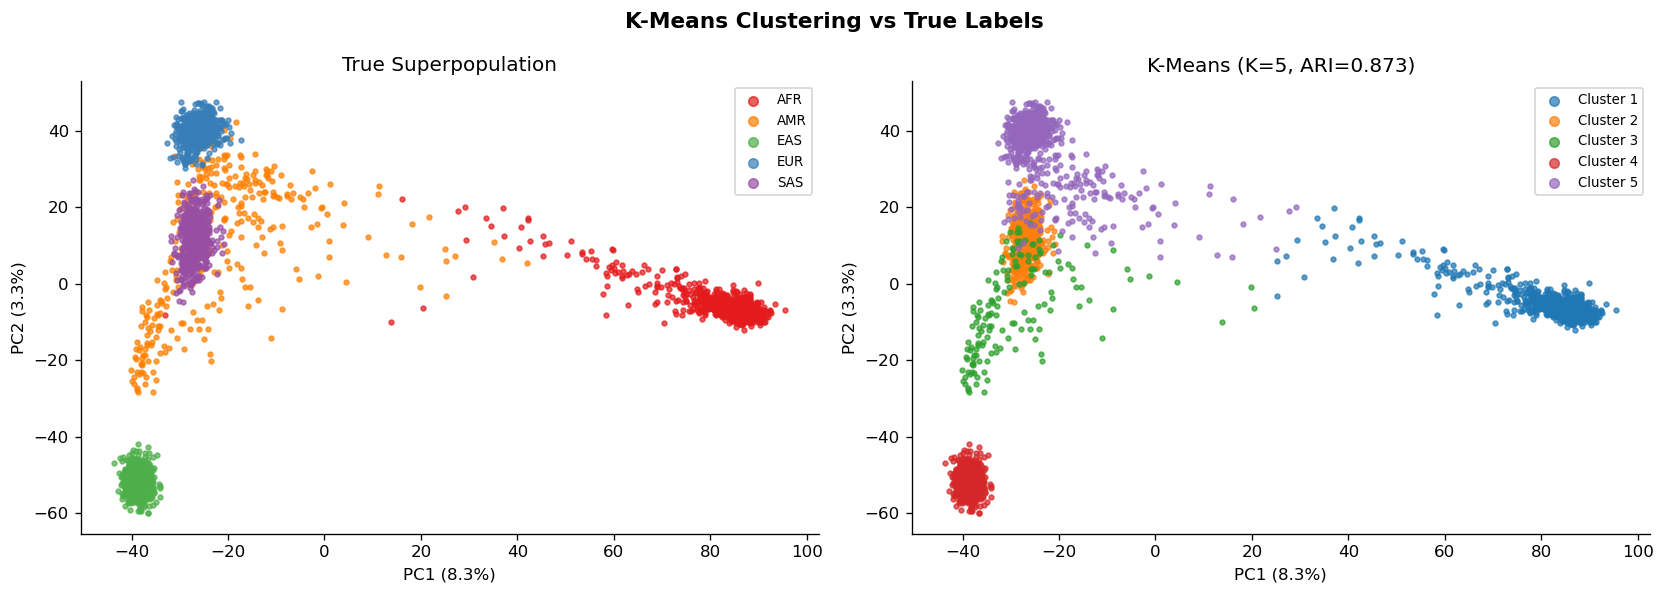

In [21]:
# K-Means
X_pca = pcs[:, :10]
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)
pc_df['kmeans_cluster'] = cluster_labels

true_labels = pd.Categorical(pc_df['super_pop']).codes
ari = adjusted_rand_score(true_labels, cluster_labels)
print(f'Adjusted Rand Index (K-Means vs superpop): {ari:.3f}')
print('  (1.0 = perfect, 0.0 = random)')

# Plot: true labels vs clusters side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sp, grp in pc_df.groupby('super_pop'):
    axes[0].scatter(grp['PC1'], grp['PC2'],
                    c=SUPER_COLORS.get(sp, '#AAA'), s=8, alpha=0.7, label=sp)
axes[0].set(xlabel=f'PC1 ({pct[0]:.1f}%)', ylabel=f'PC2 ({pct[1]:.1f}%)',
            title='True Superpopulation')
axes[0].legend(markerscale=2, fontsize=8)

palette = sns.color_palette('tab10', N_CLUSTERS)
for k in range(N_CLUSTERS):
    mask = pc_df['kmeans_cluster'] == k
    axes[1].scatter(pc_df.loc[mask, 'PC1'], pc_df.loc[mask, 'PC2'],
                    c=[palette[k]], s=8, alpha=0.7, label=f'Cluster {k+1}')
axes[1].set(xlabel=f'PC1 ({pct[0]:.1f}%)', ylabel=f'PC2 ({pct[1]:.1f}%)',
            title=f'K-Means (K={N_CLUSTERS}, ARI={ari:.3f})')
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle('K-Means Clustering vs True Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_kmeans.png', bbox_inches='tight')
plt.show()

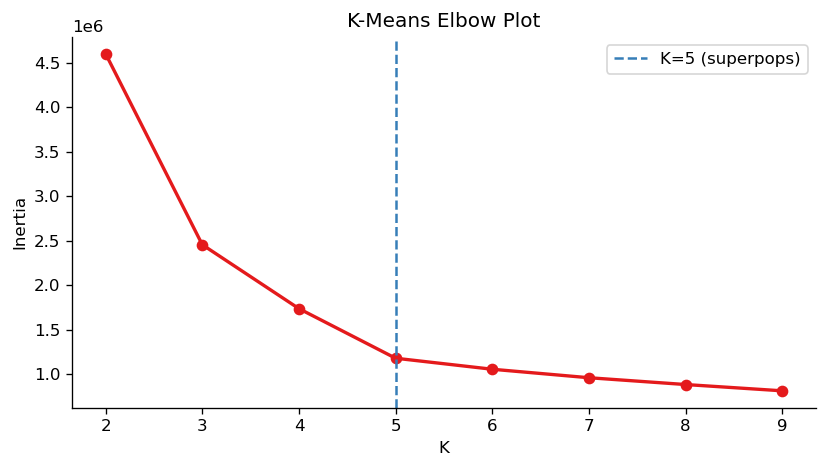

In [22]:
# Elbow plot
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'o-', color='#E41A1C', lw=2)
ax.axvline(N_CLUSTERS, ls='--', color='#377EB8', label=f'K={N_CLUSTERS} (superpops)')
ax.set(xlabel='K', ylabel='Inertia', title='K-Means Elbow Plot')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_kmeans_elbow.png', bbox_inches='tight')
plt.show()

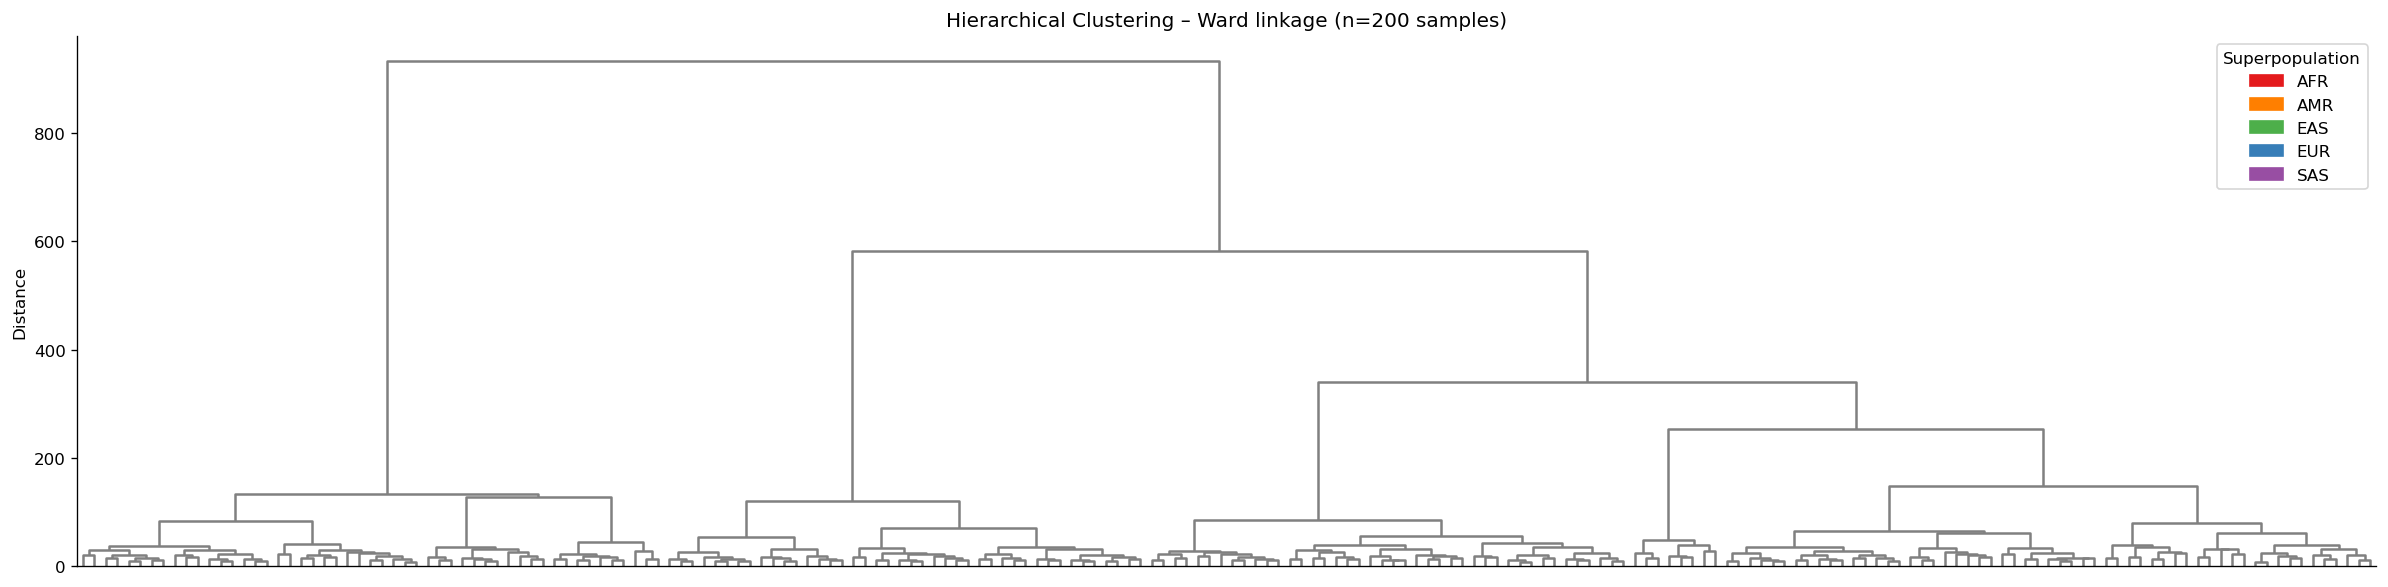

In [23]:
# Hierarchical clustering dendrogram (200 sample subset)
np.random.seed(42)
n_sub = min(200, len(X_pca))
idx   = np.random.choice(len(X_pca), size=n_sub, replace=False)
X_sub = X_pca[idx]
sp_sub = pc_df['super_pop'].iloc[idx].values

Z = linkage(X_sub, method='ward')

fig, ax = plt.subplots(figsize=(20, 5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0,
           above_threshold_color='grey')
handles = [mpatches.Patch(color=v, label=k) for k, v in SUPER_COLORS.items()]
ax.legend(handles=handles, title='Superpopulation', loc='upper right')
ax.set(title=f'Hierarchical Clustering – Ward linkage (n={n_sub} samples)',
       ylabel='Distance')
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_dendrogram.png', bbox_inches='tight')
plt.show()

---
## 7. Supervised Classification

Predict superpopulation from STR genotypes using the top 10 PCs as features.

Models:
- **Random Forest**
- **SVM (RBF kernel)**

In [24]:
X_clf = pcs[:, :10]
y_clf = pc_df['super_pop'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_clf, y_clf, cv=cv, scoring='accuracy')
print(f'Random Forest : {rf_scores.mean():.3f} +/- {rf_scores.std():.3f}')

# SVM
svm = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', random_state=42))])
svm_scores = cross_val_score(svm, X_clf, y_clf, cv=cv, scoring='accuracy')
print(f'SVM (RBF)     : {svm_scores.mean():.3f} +/- {svm_scores.std():.3f}')

Random Forest : 0.990 +/- 0.004
SVM (RBF)     : 0.990 +/- 0.005


              precision    recall  f1-score   support

         AFR       0.99      0.99      0.99       132
         AMR       1.00      0.97      0.99        69
         EAS       1.00      1.00      1.00       101
         EUR       0.99      1.00      1.00       101
         SAS       0.99      1.00      0.99        98

    accuracy                           0.99       501
   macro avg       0.99      0.99      0.99       501
weighted avg       0.99      0.99      0.99       501



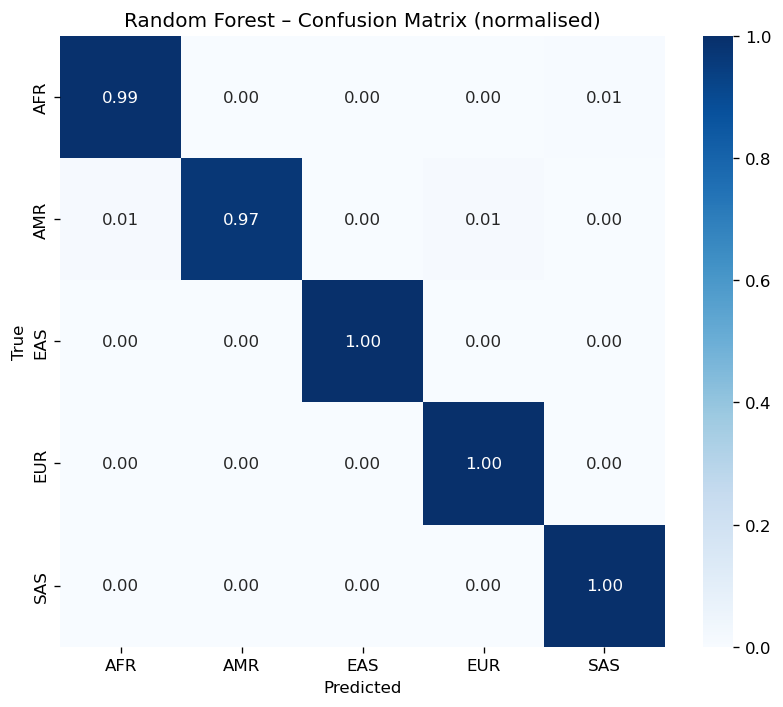

In [25]:
# Confusion matrix (Random Forest on 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

labels = sorted(np.unique(y_clf))
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax, vmin=0, vmax=1)
ax.set(xlabel='Predicted', ylabel='True',
       title='Random Forest – Confusion Matrix (normalised)')
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_rf_confusion.png', bbox_inches='tight')
plt.show()

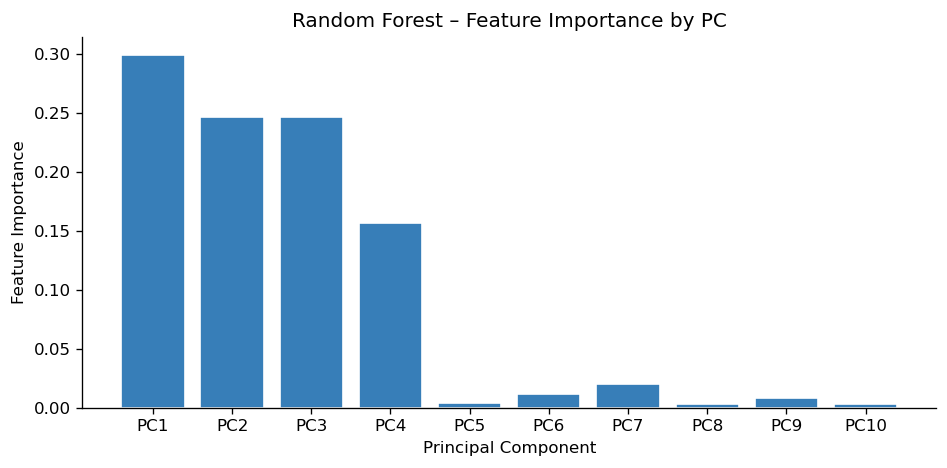

In [26]:
# Feature importance by PC
importances = rf.feature_importances_
pc_names = [f'PC{i+1}' for i in range(10)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pc_names, importances, color='#377EB8', edgecolor='white')
ax.set(xlabel='Principal Component', ylabel='Feature Importance',
       title='Random Forest – Feature Importance by PC')
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_rf_importance.png', bbox_inches='tight')
plt.show()

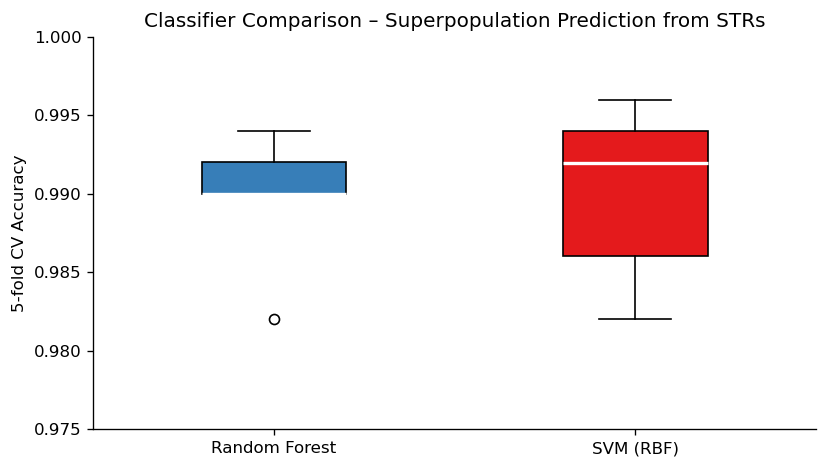

Random Forest : 0.990 +/- 0.004
SVM (RBF)     : 0.990 +/- 0.005


In [32]:
# Classifier comparison boxplot
fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot([rf_scores, svm_scores], patch_artist=True,
                widths=0.4, medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], ['#377EB8', '#E41A1C']):
    patch.set_facecolor(color)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Random Forest', 'SVM (RBF)'])
ax.set(ylabel='5-fold CV Accuracy',
       title='Classifier Comparison – Superpopulation Prediction from STRs')
ax.set_ylim(0.975, 1.0)
plt.tight_layout()
plt.savefig(PLOTDIR / 'str_classifier_comparison.png', bbox_inches='tight')
plt.show()

print(f'Random Forest : {rf_scores.mean():.3f} +/- {rf_scores.std():.3f}')
print(f'SVM (RBF)     : {svm_scores.mean():.3f} +/- {svm_scores.std():.3f}')

# Comparison STRs & SNPs


* Both STRs and SNPs managed to separate the 5 superpopulations in PCA. STRs are highly polymorphic, so fewer are needed to display population structure compared to SNPs.

__Classification accuracy__
* ~ 0.99 accuracy for both Random Forest and SVM on STRs

### Key differences between the two marker types
| | SNPs | STRs |
|---|---|---|
| Type | Biallelic | Multiallelic |
| Loci used | ~10,000 (after LD pruning) | All filtered loci |
| Information per locus | Low | High |
| Mutation rate | Low (~10⁻⁸ per generation) | High (~10⁻⁴ per generation) |
| LD structure | Strong — requires pruning | Weaker — less of a concern |
| Genotyping cost | Cheap at scale | More expensive/complex |
| Best use case | GWAS, large cohorts | Forensics, fine-scale ancestry |

### Results comparison
| | SNPs (Exercise 1) | STRs (Exercise 2) |
|---|---|---|
| Method | ADMIXTURE (probabilistic) | K-Means + RF/SVM (geometric/ML) |
| Population separation | Clean 5-group structure | Clean 5-group structure |
| Classification accuracy | — | ~0.99 (RF and SVM) |
| Loci required | ~10,000 | Fewer (higher info per locus) |